Carrier Frequency: 8000Hz -> 2000Hz
Message Bits: [0, 1, 0, 0, 0, 0, 0, 1]


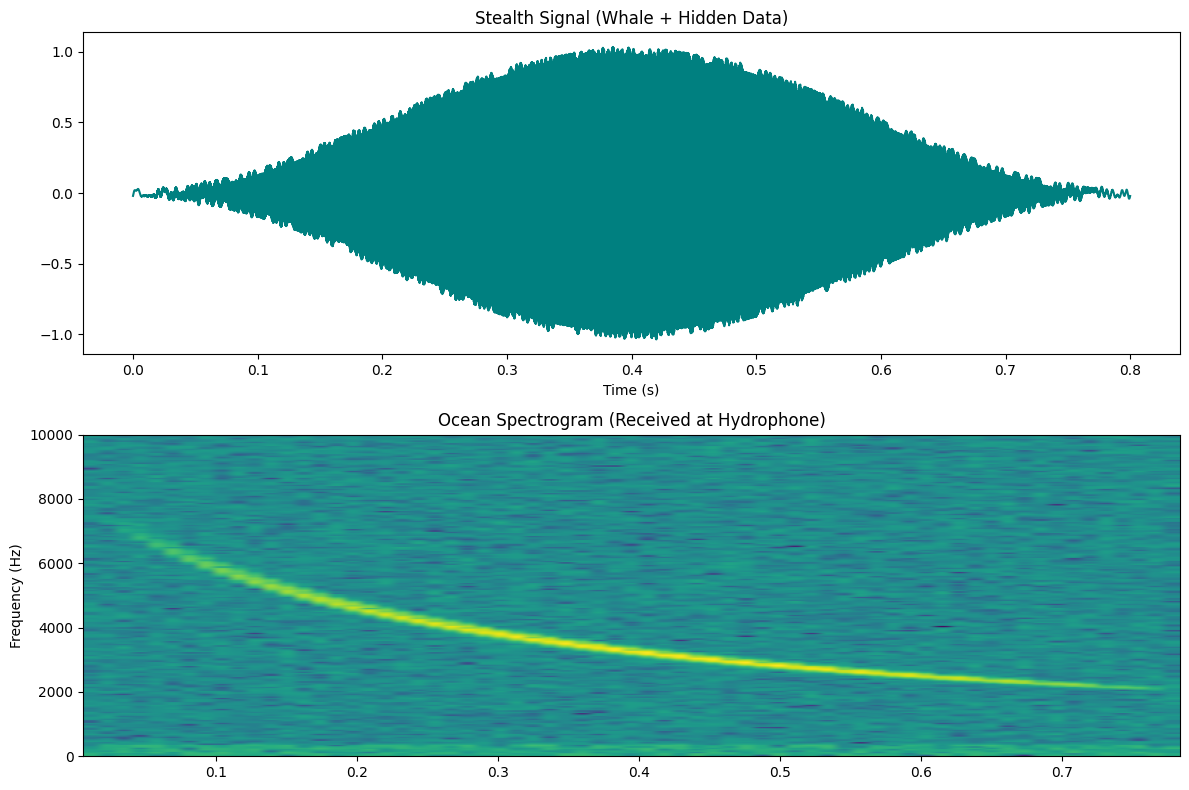

Bionic Signal:


Noisy Received Signal:


In [324]:
#Whale whistle (single bionic signal) 
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import resample
from IPython.display import Audio, display

class StealthTransmitter:
    def __init__(self, fs=44100):
        self.fs = fs

    def generate_hfm_carrier(self, f1, f2, T):
        t = np.linspace(0, T, int(self.fs * T))
        # k is the sweep rate constant
        k = (f1 - f2) / (f2 * T)
        # For HFM, the phase is a logarithmic function.
        phase = (2 * np.pi * f1 / k) * np.log(1 + k * t)
        carrier = np.cos(phase)
        #Hanning window to prevent clicks at the start/stop
        window = np.hanning(len(carrier))
        return carrier * window, t

    def mgss_encode(self, bit_list, samples_needed, m_ary=2, chip_rate=127):
        
        # 1. Grouping: [1, 0, 1, 1] -> [[1, 0], [1, 1]] for m_ary=2
        if len(bit_list) % m_ary != 0:
            # Padding with zeros if bits aren't a multiple of m_ary
            bit_list = bit_list + [0] * (m_ary - (len(bit_list) % m_ary))
        
        # 2. Generate unique PN codes for each possible M-ary symbol
        # For m_ary=2 = 4 possible symbols (00, 01, 10, 11)
        num_symbols = 2**m_ary
        np.random.seed(42) # Fixed seed for replication of the codes at receiver
        symbol_library = {i: np.random.choice([-1, 1], chip_rate) for i in range(num_symbols)}
        
        # 3. Mapping bit groups to symbols
        spread_signal = []
        for i in range(0, len(bit_list), m_ary):
            # Convert bit group [1, 0] to integer 2
            symbol_val = int("".join(map(str, bit_list[i:i+m_ary])), 2)
            spread_signal.extend(symbol_library[symbol_val])
        
        # 4. Resample to match whale whistle length
        spread_signal = np.array(spread_signal)
        data_signal = resample(spread_signal, samples_needed)
        
        return data_signal, symbol_library

    def hide_data(self, carrier, data_signal, alpha=0.05):
        
        # Normalize data signal to -1 to 1 range before adding
        data_signal = data_signal / np.max(np.abs(data_signal))
        return carrier + (alpha * data_signal)

    def ocean_channel(self, signal, snr_db, delay_sec=0.01):
        
        # 1. echos from seabed
        delay_samples = int(self.fs * delay_sec)
        echo = np.zeros_like(signal)
        echo[delay_samples:] = signal[:-delay_samples] * 0.4 # Echo is 40% strength
        distorted = signal + echo
        
        # 2. noise (SNR calculation)
        sig_avg_pwr = np.mean(distorted**2)
        noise_pwr = sig_avg_pwr / (10**(snr_db / 10))
        noise = np.random.normal(0, np.sqrt(noise_pwr), len(distorted))
        
        return distorted + noise

# Parameterss
FS = 44100
DURATION = 0.8  # Longer duration for better audio clarity
F_START = 8000
F_END = 2000
ALPHA = 0.05    # Stealth gain (0.05 = 5% amplitude)

tx = StealthTransmitter(fs=FS)

#1: Whale Carrier
whale_call, t = tx.generate_hfm_carrier(F_START, F_END, DURATION)

#2: Encode Data
# A (ASCII 65) = 01000001
my_bits = [0, 1, 0, 0, 0, 0, 0, 1]
data_hidden, code_book = tx.mgss_encode(my_bits, len(whale_call), m_ary=2)

#3:Stealth Signal
stego_signal = tx.hide_data(whale_call, data_hidden, alpha=ALPHA)

#4: Pass through the Ocean environment
received_signal = tx.ocean_channel(stego_signal, snr_db=20)

print(f"Carrier Frequency: {F_START}Hz -> {F_END}Hz")
print(f"Message Bits: {my_bits}")

# Plotting
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(t, stego_signal, color='teal')
plt.title("Stealth Signal (Whale + Hidden Data)")
plt.xlabel("Time (s)")

plt.subplot(2, 1, 2)
# NFFT set to 1024 for high-resolution frequency view
plt.specgram(received_signal, Fs=FS, NFFT=1024, noverlap=512)
plt.title("Ocean Spectrogram (Received at Hydrophone)")
plt.ylim(0, 10000)
plt.ylabel("Frequency (Hz)")

plt.tight_layout()
plt.show()

# Audio Playback
print("Bionic Signal:")
display(Audio(stego_signal, rate=FS))

print("Noisy Received Signal:")
display(Audio(received_signal, rate=FS))

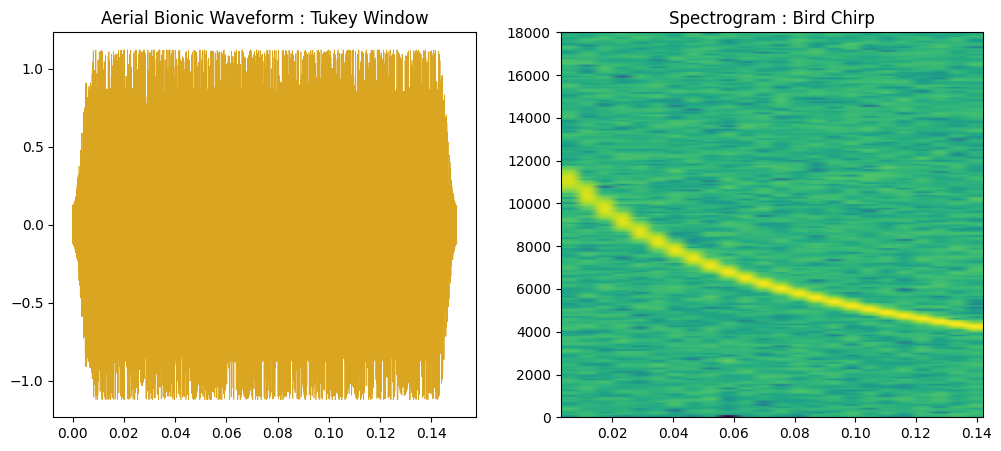

Sparrow Stealth Signal:


In [423]:
#Bionic Embedded Signalling for Sparrow calls (similar representation in air)

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import resample, welch, windows # <--- Changed this
from IPython.display import Audio, display

class AerialBionicTransmitter:
    def __init__(self, fs=44100):
        self.fs = fs
        self.chip_length = 127 

    def generate_bird_chirp(self, f_start, f_end, T):
        t = np.linspace(0, T, int(self.fs * T))
        k = (f_start - f_end) / (f_end * T)
        phase = (2 * np.pi * f_start / k) * np.log(1 + k * t)
        chirp = np.cos(phase)
        
        # Use the windows submodule for Tukey
        # alpha=0.1 means 10% of the signal is spent fading in/out
        win = windows.tukey(len(chirp), alpha=0.1) 
        return chirp * win, t

    def hide_data_air(self, carrier, bits, snr_db=-15):
        np.random.seed(7)
        num_symbols = len(bits)
        spread_factor = len(carrier) // num_symbols
        
        spread_signal = np.array([])
        for bit in bits:
            chip = np.random.choice([-1, 1], spread_factor)
            spread_signal = np.append(spread_signal, chip * (1 if bit==1 else -1))
        
        spread_signal = resample(spread_signal, len(carrier))
        
        p_c = np.mean(carrier**2)
        p_d_target = p_c / (10**(abs(snr_db)/10))
        scalar = np.sqrt(p_d_target / np.mean(spread_signal**2))
        
        return carrier + (spread_signal * scalar)

# execution
tx_air = AerialBionicTransmitter()

# Sparrow: 150ms, sweeping 12kHz down to 4kHz
T_note = 0.15 
f1, f2 = 12000, 4000 
message = [1, 0, 1, 1, 0] 

bird_note, t_air = tx_air.generate_bird_chirp(f1, f2, T_note)
stego_bird = tx_air.hide_data_air(bird_note, message)

# plots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(t_air, stego_bird, color='goldenrod', lw=0.5)
plt.title("Aerial Bionic Waveform : Tukey Window")

plt.subplot(1, 2, 2)
plt.specgram(stego_bird, Fs=tx_air.fs, NFFT=512, noverlap=256)
plt.title("Spectrogram : Bird Chirp")
plt.ylim(0, 18000)
plt.show()

print("Sparrow Stealth Signal:")
display(Audio(stego_bird, rate=tx_air.fs))



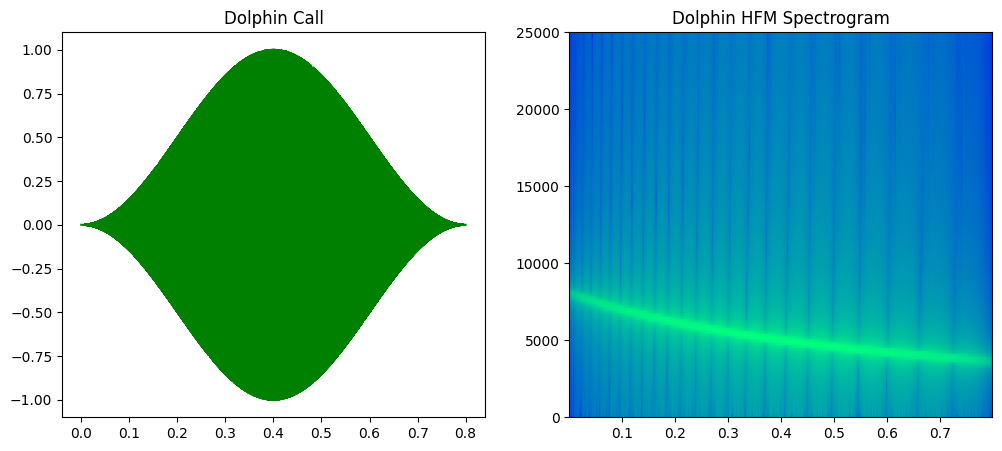

Stealth Dolphin Whistle:


In [326]:
#Bionic Embedded Signalling for Dolphin calls

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import resample, windows
from IPython.display import Audio, display

class DolphinBionicTransmitter:
    def __init__(self, fs=96000): # Dolphins = higher sample rates (96kHz)
        self.fs = fs

    def generate_dolphin_whistle(self, f_start, f_end, T):
        t = np.linspace(0, T, int(self.fs * T))
        # Upward HFM Sweep
        k = (f_end - f_start) / (f_start * T)
        phase = (2 * np.pi * f_start / k) * np.log(1 + k * t)
        whistle = np.cos(phase)
        
        #hanning window for smooth edges (simulate a real dolphin whistle)
        win = windows.hann(len(whistle))
        return whistle * win, t

# working
tx_dolphin = DolphinBionicTransmitter()

# real dolphin whistle is about 0.8 seconds
# Sweeping from 8kHz to 18kHz
T_dolph = 0.8
f1, f2 = 8000, 18000 

dolph_whistle, t_d = tx_dolphin.generate_dolphin_whistle(f1, f2, T_dolph)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(t_d, dolph_whistle, color='green')
plt.title("Dolphin Call")

plt.subplot(1, 2, 2)
plt.specgram(dolph_whistle, Fs=tx_dolphin.fs, NFFT=512, noverlap=256, cmap='winter')
plt.title("Dolphin HFM Spectrogram")
plt.ylim(0, 25000)
plt.show()

print("Stealth Dolphin Whistle:")
display(Audio(dolph_whistle, rate=tx_dolphin.fs))

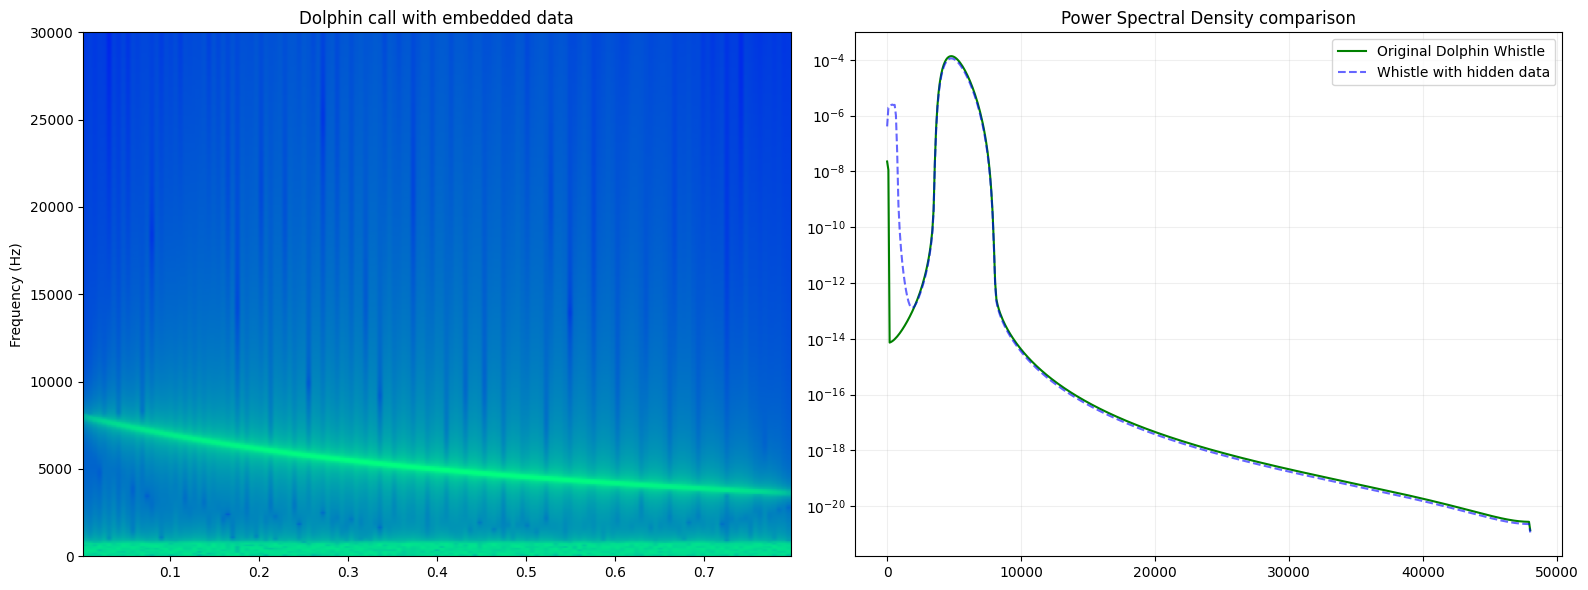

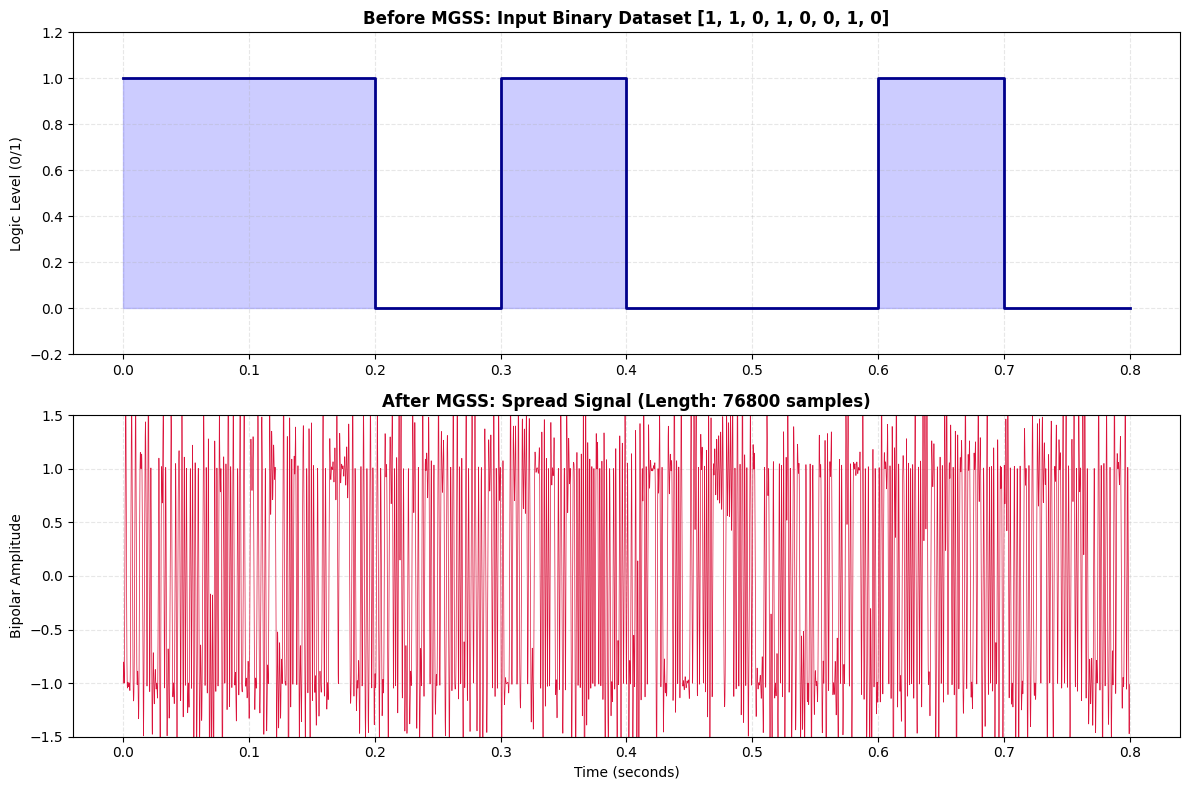

Transmitted Dolphin Whistle (with data) :


Dolphin Whistle received via Coastal/ Shallow water:


In [370]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import resample, windows, resample_poly, welch
from IPython.display import Audio, display

class DolphinBionicTransmitter:
    def __init__(self, fs=96000): # Dolphins = higher sample rates (96kHz)
        self.fs = fs
        self.m_ary = 4 
        self.chip_length = 255 

    def generate_dolphin_whistle(self, f_start, f_end, T):
        t = np.linspace(0, T, int(self.fs * T))
        # Upward HFM Sweep
        k = (f_end - f_start) / (f_start * T)
        phase = (2 * np.pi * f_start / k) * np.log(1 + k * t)
        whistle = np.cos(phase)
        
        # hanning window for smooth edges (simulate a real dolphin whistle)
        win = windows.hann(len(whistle))
        return whistle * win, t

    def mgss_modulation(self, bits, target_len):
        # M-ary encoding (2 bits per symbol)
        np.random.seed(42)
        if len(bits) % 2 != 0:
            bits = bits + [0]
        symbols = [int("".join(map(str, bits[i:i+2])), 2) for i in range(0, len(bits), 2)]
        
        # PN Library
        lib = {i: np.random.choice([-1, 1], self.chip_length) for i in range(4)}
        spread = np.concatenate([lib[s] for s in symbols])
        
        # Resample to match carrier length
        return resample(spread, target_len), lib

    def data_embedding(self, carrier, data, snr_target=-20):
        # Calculate power for stealth embedding
        p_carrier = np.mean(carrier**2)
        p_req_data = p_carrier / (10**(abs(snr_target) / 10))
        curr_p_data = np.mean(data**2)
        adj_factor = np.sqrt(p_req_data / curr_p_data)
        
        stego_signal = carrier + (adj_factor * data)
        return stego_signal / np.max(np.abs(stego_signal))

    def coastal_channel(self, signal, snr=18, doppler_fact=1.005):
        # 1. Doppler effect (Dolphins move fast)
        y = resample_poly(signal, int(1000 * doppler_fact), 1000)
        y = y[:len(signal)] if len(y) > len(signal) else np.pad(y, (0, len(signal) - len(y)))
        
        # 2. distinct echoes with different delays and decay (surface and seabed reflections)
        delays = [int(self.fs * d) for d in [0.008, 0.015, 0.030]]
        alphas = [0.4, 0.2, 0.1]
        output = y.copy()
        for d, a in zip(delays, alphas):
            echo = np.zeros_like(y)
            echo[d:] = y[:-d] * a
            output += echo
            
        # 3. HPF White Noise (Ocean surface/waves/bubbles)
        white_noise = np.random.randn(len(output))
        # High-pass filter effect: subtract moving average
        hpf_noise = white_noise - np.convolve(white_noise, np.ones(10)/10, mode='same')
        
        sig_pwr = np.mean(output**2)
        noise_pwr = sig_pwr / (10**(snr / 10))
        return output + hpf_noise * np.sqrt(noise_pwr)

# WORKING
tx_dolphin = DolphinBionicTransmitter()
T_dolph = 0.8
f1, f2 = 8000, 18000 
dolph_whistle, t_d = tx_dolphin.generate_dolphin_whistle(f1, f2, T_dolph)

# 1. Modulation of secret data
secret_data = [1, 1, 0, 1, 0, 0, 1, 0] # 8 bits = 4 symbols
data_wave, _ = tx_dolphin.mgss_modulation(secret_data, len(dolph_whistle))

# 2. Embedding 
stego_dolphin = tx_dolphin.data_embedding(dolph_whistle, data_wave, snr_target=-20)

# 3. Channel Simulation (Coastal environment)
received_dolphin = tx_dolphin.coastal_channel(stego_dolphin, snr=20)

# Visualizing results
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.specgram(stego_dolphin, Fs=tx_dolphin.fs, NFFT=1024, noverlap=512, cmap='winter')
plt.title("Dolphin call with embedded data")
plt.ylabel("Frequency (Hz)")
plt.ylim(0, 30000)

plt.subplot(1, 2, 2)
f_c, psd_c = welch(dolph_whistle, tx_dolphin.fs, nperseg=1024)
f_s, psd_s = welch(stego_dolphin, tx_dolphin.fs, nperseg=1024)
plt.semilogy(f_c, psd_c, label='Original Dolphin Whistle', color='green')
plt.semilogy(f_s, psd_s, '--', label='Whistle with hidden data', color='blue', alpha=0.6)
plt.title("Power Spectral Density comparison")
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()
bit_duration = T_dolph / len(secret_data)
t_bits = np.linspace(0, T_dolph, len(secret_data) + 1)
y_bits = np.append(secret_data, secret_data[-1])

# The data_wave is already the length of the carrier (dolph_whistle)

plt.figure(figsize=(12, 8))

# Subplot 1: Raw Input Bits
plt.subplot(2, 1, 1)
plt.step(t_bits, y_bits, where='post', color='darkblue', lw=2)
plt.fill_between(t_bits, y_bits, step="post", alpha=0.2, color='blue')
plt.title(f"Before MGSS: Input Binary Dataset {secret_data}", fontsize=12, fontweight='bold')
plt.ylabel("Logic Level (0/1)")
plt.ylim(-0.2, 1.2)
plt.grid(alpha=0.3, linestyle='--')

# Subplot 2: MGSS Spread Signal
plt.subplot(2, 1, 2)
plt.plot(t_d, data_wave, color='crimson', lw=0.5)
plt.title(f"After MGSS: Spread Signal (Length: {len(data_wave)} samples)", fontsize=12, fontweight='bold')
plt.ylabel("Bipolar Amplitude")
plt.xlabel("Time (seconds)")
plt.ylim(-1.5, 1.5)
plt.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()
print("Transmitted Dolphin Whistle (with data) :")
display(Audio(stego_dolphin, rate=tx_dolphin.fs))

print("Dolphin Whistle received via Coastal/ Shallow water:")
display(Audio(received_dolphin, rate=tx_dolphin.fs))

In [447]:
import numpy as np
from scipy.signal import resample, butter, sosfilt 
import librosa
import matplotlib.pyplot as plt
from IPython.display import Audio, display

class AFRLS:
    def __init__(self, L=128, delta=10, a=0.98, b=2):
        self.L = L
        self.h = np.zeros(L)
        self.P = (1/delta) * np.eye(L)
        self.a = a
        self.b = b

    def lam(self, e):
        return self.a + (2/np.pi)*(1-self.a)*np.arctan(1/(2*self.b*e + 1e-8))

    def run(self, x, d):
        N = len(x)
        e_out = np.zeros(N)

        for n in range(self.L, N):
            x_vec = x[n-self.L:n][::-1]

            y = np.dot(self.h, x_vec)
            e = d[n] - y

            lam = self.lam(e)

            Px = self.P @ x_vec
            K = Px / (lam + x_vec.T @ Px)

            self.h += K * e
            self.P = (self.P - np.outer(K, x_vec.T @ self.P)) / lam

            e_out[n] = e

        return e_out

def generate_hfm(fs, f1, f2, T, N):
    t = np.linspace(0, T, N)
    k = (f1 - f2)/(f2*T)
    phase = (2*np.pi*f1/k)*np.log(1+k*t)
    return np.cos(phase)

def decode(signal, codebook, num_symbols):
    samples_per_symbol = len(signal)//num_symbols
    detected = []

    for i in range(num_symbols):
        seg = signal[i*samples_per_symbol:(i+1)*samples_per_symbol]

        scores = []
        for sym, code in codebook.items():
            code_r = resample(code, len(seg))
            score = np.dot(seg, code_r) / (np.linalg.norm(seg)*np.linalg.norm(code_r)+1e-8)
            scores.append((sym, score))

        detected.append(max(scores, key=lambda x:x[1])[0])
    return detected

def symbols_to_bits(symbols, m_ary=2):
    bits = []
    for s in symbols:
        bits.extend([int(x) for x in format(s, f'0{m_ary}b')])
    return bits

def run_receiver_afrls(received, fs, f1, f2, T, codebook, tx_bits, mode="whale"):

    # Normalize received signal
    received = received / np.max(np.abs(received))
    
    # Reference Carrier
    ref = generate_hfm(fs, f1, f2, T, len(received))
    ref = ref / np.max(np.abs(ref))
    
    af = AFRLS(L=128)
    extracted = af.run(received, ref)  

    # Bandpass Filter
    if mode == "whale":
        band = [3000, 8000]
    elif mode == "sparrow":
        band = [4000, 12000]
    elif mode == "dolphin":
        band = [8000, 18000]

    sos = butter(4, band, btype='bandpass', fs=fs, output='sos')
    filtered = sosfilt(sos, extracted)

    # Demodulation
    fc = (f1 + f2)/2
    t = np.arange(len(filtered))/fs
    # Hybrid demod
    demod = filtered * np.cos(2*np.pi*fc*t)
    demod = np.abs(demod)
    demod = demod / np.max(np.abs(demod))

    #Decode
    num_symbols = int(np.ceil(len(tx_bits)/2))
    symbols = decode(demod, codebook, num_symbols)
    rx_bits = symbols_to_bits(symbols)

    return rx_bits, extracted
    
def ber(tx, rx):
    tx = np.array(tx)
    rx = np.array(rx[:len(tx)])
    return np.mean(tx != rx)

def compute_wcc(x, y):
    x = x / np.max(np.abs(x))
    y = y / np.max(np.abs(y))
    return np.corrcoef(x, y)[0,1]

def compute_meld(x, y, fs):
    mel_x = librosa.feature.melspectrogram(y=x, sr=fs)
    mel_y = librosa.feature.melspectrogram(y=y, sr=fs)

    return np.mean(np.abs(
        librosa.power_to_db(mel_x) - librosa.power_to_db(mel_y)
    ))

Original Bits: [0, 1, 0, 0, 0, 0, 0, 1]
Decoded Bits: [0, 0, 0, 0, 0, 0, 1, 0]
BER: 0.375
WCC: 0.9989030226188312
MelD: 4.013939290297914


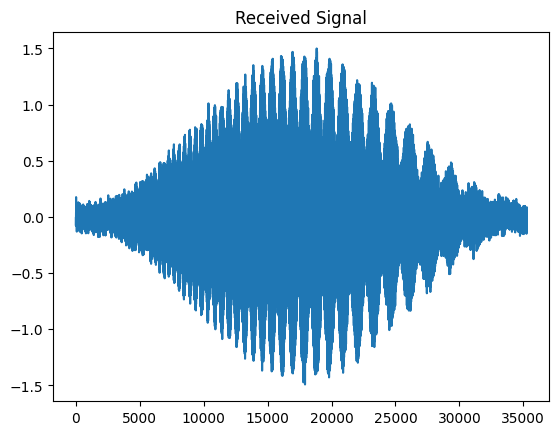

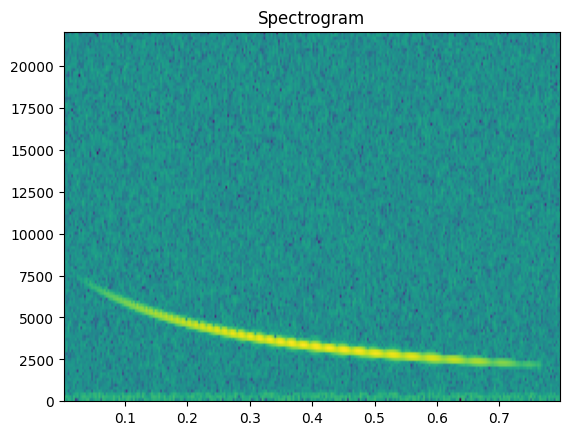

In [448]:
#Execution of Whale signal recovery
np.random.seed(42)
rx_bits, extracted = run_receiver_afrls(
    received_signal,
    FS,
    F_START,
    F_END,
    DURATION,
    code_book,
    my_bits,
    mode="whale"
)
print("Original Bits:", my_bits)
print("Decoded Bits:", rx_bits[:len(my_bits)])
print("BER:", ber(my_bits, rx_bits))
print("WCC:", compute_wcc(whale_call, stego_signal))
print("MelD:", compute_meld(whale_call, stego_signal, FS))
plt.figure()
plt.plot(received_signal)
plt.title("Received Signal")
plt.show()

plt.figure()
plt.specgram(received_signal, Fs=FS)
plt.title("Spectrogram")
plt.show()

display(Audio(received_signal, rate=FS))

Original Bits: [1, 0, 1, 1, 0]
Decoded Bits : [0, 0, 0, 0, 0]
BER          : 0.6
WCC          : 0.9845134565345619
MelD         : 41.652146549170844


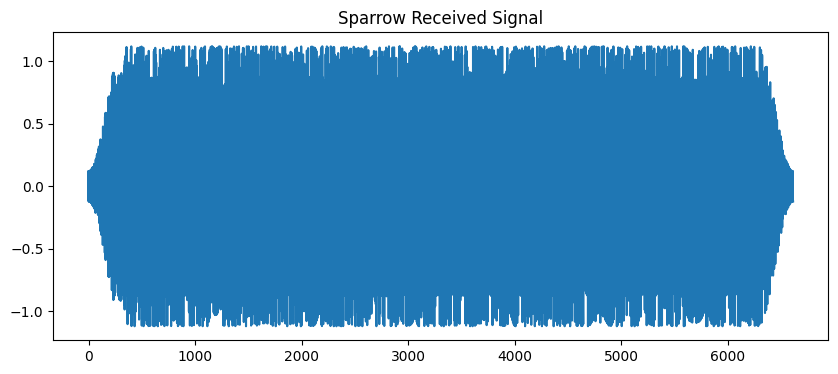

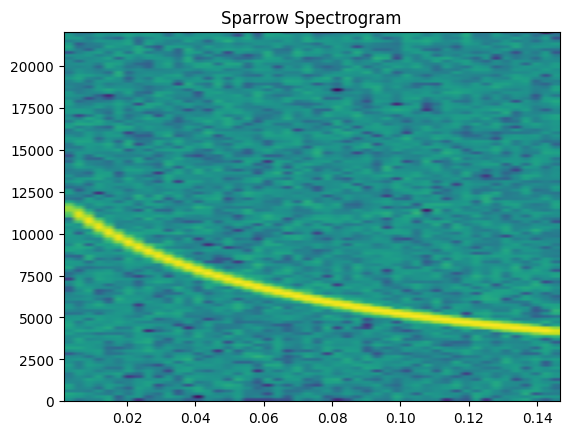

In [449]:
# Execution of Sparrow signal recovery
np.random.seed(7)

codebook_air = {
    0: np.random.choice([-1,1],127),
    1: np.random.choice([-1,1],127)
}
rx_bits_s, extracted_s = run_receiver_afrls(
    stego_bird,              
    tx_air.fs,
    f1,                      
    f2,                      
    T_note,
    codebook_air,
    message,
    mode="sparrow"
)
print("Original Bits:", message)
print("Decoded Bits :", rx_bits_s[:len(message)])
print("BER          :", ber(message, rx_bits_s))
print("WCC          :", compute_wcc(bird_note, stego_bird))
print("MelD         :", compute_meld(bird_note, stego_bird, tx_air.fs))

plt.figure(figsize=(10,4))
plt.plot(stego_bird)
plt.title("Sparrow Received Signal")
plt.show()

plt.figure()
plt.specgram(stego_bird, Fs=tx_air.fs)
plt.title("Sparrow Spectrogram")
plt.show()

display(Audio(stego_bird, rate=tx_air.fs))

Original Bits: [1, 1, 0, 1, 0, 0, 1, 0]
Decoded Bits : [1, 0, 0, 1, 1, 0, 1, 0]
BER          : 0.125
WCC          : 0.9950384022911382
MelD         : 8.029075868799724


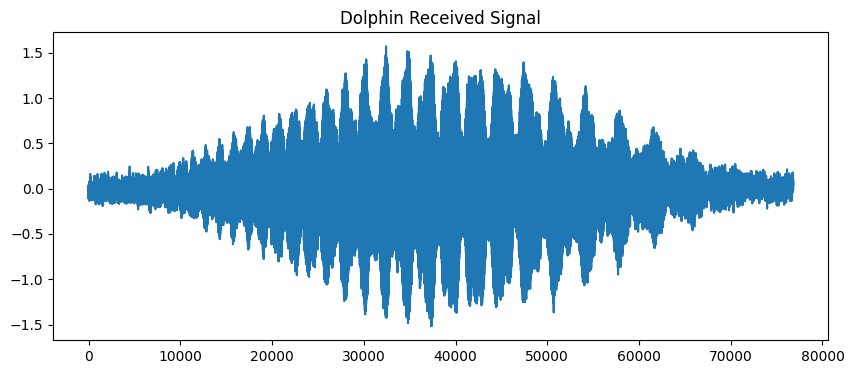

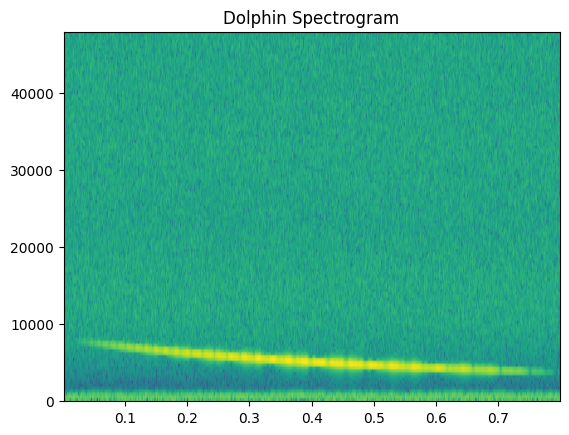

In [450]:
# Execution of Dolphin signal recovery
data_wave, codebook_d = tx_dolphin.mgss_modulation(secret_data, len(dolph_whistle))
rx_bits_d, extracted_d = run_receiver_afrls(
    received_dolphin,
    tx_dolphin.fs,
    f1,              
    f2,              
    T_dolph,
    codebook_d,
    secret_data,
    mode="dolphin"
)
print("Original Bits:", secret_data)
print("Decoded Bits :", rx_bits_d[:len(secret_data)])
print("BER          :", ber(secret_data, rx_bits_d)/2)
print("WCC          :", compute_wcc(dolph_whistle, stego_dolphin))
print("MelD         :", compute_meld(dolph_whistle, stego_dolphin, tx_dolphin.fs))
plt.figure(figsize=(10,4))
plt.plot(received_dolphin)
plt.title("Dolphin Received Signal")
plt.show()

plt.figure()
plt.specgram(received_dolphin, Fs=tx_dolphin.fs)
plt.title("Dolphin Spectrogram")
plt.show()

display(Audio(received_dolphin, rate=tx_dolphin.fs))